# 🤖 Notebook 05 — Modeling: Anomaly Detection & Crisis Classification
## Early Warning System Krisis Pariwisata Bali — BaliGuard

Notebook ini membangun **dua model machine learning**:
1. **Isolation Forest** — anomaly detection (unsupervised), mendeteksi bulan anomali tanpa perlu label
2. **Random Forest Classifier** — klasifikasi level krisis (supervised), memprediksi AMAN/WASPADA/SIAGA/KRISIS

Dilengkapi **SHAP** untuk explainability — fitur mana yang paling berkontribusi ke prediksi krisis.

**Input:** `data/final/master_dataset_clean.parquet`  
**Output:** `data/final/model_isolation_forest.pkl`, `data/final/model_random_forest.pkl`, `data/final/predictions_final.csv`

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.pipeline import Pipeline
import joblib
import os

# SHAP
try:
    import shap
    print('✅ SHAP tersedia')
except ImportError:
    print('⚠️  SHAP belum terinstall — jalankan: pip install shap')

print('✅ Semua library berhasil diimport')
print(f'Pandas: {pd.__version__} | Numpy: {np.__version__}')

✅ SHAP tersedia
✅ Semua library berhasil diimport
Pandas: 2.3.3 | Numpy: 2.2.6


## 2. Load Dataset

In [2]:
# Load master dataset
df = pd.read_parquet('data/final/master_dataset_clean.parquet')

print('=== DATASET OVERVIEW ===')
print(f'Shape: {df.shape}')
print(f'Periode: {df["month"].min()} → {df["month"].max()}')
print()
print('Distribusi Crisis Level:')
dist = df['crisis_level'].value_counts()
for level, count in dist.items():
    pct = count/len(df)*100
    bar = '█' * int(pct/2)
    print(f'  {level:8s}: {count:3d} ({pct:.1f}%) {bar}')
print()
print('Missing values per fitur:')
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else '  Tidak ada null ✅')

=== DATASET OVERVIEW ===
Shape: (192, 31)
Periode: 2009-01 → 2024-12

Distribusi Crisis Level:
  WASPADA : 147 (76.6%) ██████████████████████████████████████
  SIAGA   :  33 (17.2%) ████████
  AMAN    :   7 (3.6%) █
  KRISIS  :   5 (2.6%) █

Missing values per fitur:
tpk_change_mom        1
tpk_ma3               2
wisman_growth_mom     3
wisman_growth_yoy    12
wisman_ma3            2
wisman_ma6            5
wisman_zscore        11
usd_volatility_3m     2
usd_change_mom        1
bali_share_change     1


## 3. Feature Selection & Preprocessing

In [3]:
# Fitur utama untuk modeling
# Dipilih berdasarkan: variasi tinggi, coverage ≥94%, relevansi domain
FEATURES = [
    # Kunjungan wisatawan
    'wisman_growth_mom',    # perubahan MoM
    'wisman_growth_yoy',    # perubahan YoY
    'wisman_zscore',        # anomali z-score
    # Ekonomi
    'usd_idr_avg',          # kurs USD/IDR
    'usd_volatility_3m',    # volatilitas kurs
    'usd_change_mom',       # perubahan kurs MoM
    # Hotel & pariwisata
    'tpk_bintang',          # tingkat hunian hotel bintang
    'tpk_change_mom',       # perubahan hunian MoM
    # Makroekonomi
    'inflasi_processed',    # inflasi bulanan
    'bali_share_pct',       # pangsa Bali dari wisman nasional
    # Sentimen
    'avg_sentiment_monthly', # sentimen review wisatawan (sekarang bervariasi)
    # Musiman
    'month_num',            # bulan (1-12) untuk seasonality
    'is_peak_season',       # flag musim puncak
]

TARGET = 'crisis_level'

# Siapkan dataframe bersih
df_model = df[FEATURES + [TARGET, 'month', 'crisis_score_100', 'wisman']].dropna().copy()

print(f'Data setelah dropna: {len(df_model)} baris (dari {len(df)} total)')
print(f'Baris yang di-drop: {len(df) - len(df_model)} (window warmup awal)')
print()
print(f'Fitur yang digunakan ({len(FEATURES)}):')
for i, f in enumerate(FEATURES, 1):
    null_pct = df[f].isnull().mean() * 100
    print(f'  {i:2d}. {f:30s} (null: {null_pct:.1f}%)')

# Label encoding untuk target
label_order = ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']
le = LabelEncoder()
le.fit(label_order)
df_model['crisis_label_enc'] = le.transform(df_model[TARGET])

print()
print('Label encoding:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} → {idx}')

Data setelah dropna: 178 baris (dari 192 total)
Baris yang di-drop: 14 (window warmup awal)

Fitur yang digunakan (13):
   1. wisman_growth_mom              (null: 1.6%)
   2. wisman_growth_yoy              (null: 6.2%)
   3. wisman_zscore                  (null: 5.7%)
   4. usd_idr_avg                    (null: 0.0%)
   5. usd_volatility_3m              (null: 1.0%)
   6. usd_change_mom                 (null: 0.5%)
   7. tpk_bintang                    (null: 0.0%)
   8. tpk_change_mom                 (null: 0.5%)
   9. inflasi_processed              (null: 0.0%)
  10. bali_share_pct                 (null: 0.0%)
  11. avg_sentiment_monthly          (null: 0.0%)
  12. month_num                      (null: 0.0%)
  13. is_peak_season                 (null: 0.0%)

Label encoding:
  AMAN → 0
  KRISIS → 1
  SIAGA → 2
  WASPADA → 3


In [4]:
# Clip outlier ekstrem di ±5 std sebelum scaling
# Mencegah recovery COVID mendominasi model secara tidak proporsional
df_model[FEATURES] = df_model[FEATURES].clip(
    lower=df_model[FEATURES].quantile(0.01),
    upper=df_model[FEATURES].quantile(0.99),
    axis=1
)

print('Setelah clip 1%-99%:')
print(f'wisman_growth_mom max: {df_model["wisman_growth_mom"].max():.3f}')
print(f'wisman_growth_yoy max: {df_model["wisman_growth_yoy"].max():.3f}')

Setelah clip 1%-99%:
wisman_growth_mom max: inf
wisman_growth_yoy max: inf


## 4. Normalisasi Fitur

In [5]:
# ─── CEK DULU SEBELUM SCALING ───
print('=== CEK INFINITY & NULL ===')
for f in FEATURES:
    inf_count = np.isinf(df_model[f]).sum()
    nan_count = np.isnan(df_model[f]).sum()
    if inf_count > 0 or nan_count > 0:
        print(f'  {f}: {inf_count} inf, {nan_count} nan')

# Ganti inf dengan NaN dulu, lalu isi dengan median kolom
df_model[FEATURES] = df_model[FEATURES].replace([np.inf, -np.inf], np.nan)
df_model[FEATURES] = df_model[FEATURES].fillna(df_model[FEATURES].median())

# Verifikasi sudah bersih
inf_total = np.isinf(df_model[FEATURES].values).sum()
nan_total = np.isnan(df_model[FEATURES].values).sum()
print(f'Setelah fix — inf: {inf_total}, nan: {nan_total}')
print()

# Standardisasi fitur
scaler = StandardScaler()
X = df_model[FEATURES].values
X_scaled = scaler.fit_transform(X)
y = df_model['crisis_label_enc'].values
months = df_model['month'].values

print('Shape X (fitur):', X_scaled.shape)
print('Shape y (target):', y.shape)
print()
print('Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):')
scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)
print(scaled_df.describe().round(2).to_string())

=== CEK INFINITY & NULL ===
  wisman_growth_mom: 2 inf, 0 nan
  wisman_growth_yoy: 4 inf, 0 nan
Setelah fix — inf: 0, nan: 0

Shape X (fitur): (178, 13)
Shape y (target): (178,)

Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):
       wisman_growth_mom  wisman_growth_yoy  wisman_zscore  usd_idr_avg  usd_volatility_3m  usd_change_mom  tpk_bintang  tpk_change_mom  inflasi_processed  bali_share_pct  avg_sentiment_monthly  month_num  is_peak_season
count             178.00             178.00         178.00       178.00             178.00          178.00       178.00          178.00             178.00          178.00                 178.00     178.00          178.00
mean                0.00               0.00          -0.00         0.00               0.00            0.00        -0.00            0.00               0.00           -0.00                   0.00      -0.00            0.00
std                 1.00               1.00           1.00         1.00               1.00            1.0

In [6]:
# Standardisasi fitur (penting untuk Isolation Forest)
scaler = StandardScaler()
X = df_model[FEATURES].values
X_scaled = scaler.fit_transform(X)
y = df_model['crisis_label_enc'].values
months = df_model['month'].values

print('Shape X (fitur):', X_scaled.shape)
print('Shape y (target):', y.shape)
print()
print('Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):')
scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)
print(scaled_df.describe().round(2).to_string())

Shape X (fitur): (178, 13)
Shape y (target): (178,)

Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):
       wisman_growth_mom  wisman_growth_yoy  wisman_zscore  usd_idr_avg  usd_volatility_3m  usd_change_mom  tpk_bintang  tpk_change_mom  inflasi_processed  bali_share_pct  avg_sentiment_monthly  month_num  is_peak_season
count             178.00             178.00         178.00       178.00             178.00          178.00       178.00          178.00             178.00          178.00                 178.00     178.00          178.00
mean                0.00               0.00          -0.00         0.00               0.00            0.00        -0.00            0.00               0.00           -0.00                   0.00      -0.00            0.00
std                 1.00               1.00           1.00         1.00               1.00            1.00         1.00            1.00               1.00            1.00                   1.00       1.00            1.00
min       

## 5. Model 1 — Isolation Forest (Anomaly Detection)

**Isolation Forest** mendeteksi anomali secara *unsupervised* — tanpa membutuhkan label.
Prinsipnya: data anomali lebih mudah "diisolasi" dalam pohon keputusan karena berbeda dari mayoritas data.

Cocok untuk early warning karena bisa mendeteksi krisis baru yang belum pernah terjadi sebelumnya.

In [7]:
# Train Isolation Forest
# contamination = perkiraan % anomali dalam data (~20% COVID + krisis lain)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # estimasi 15% data adalah anomali
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

# Prediksi: -1 = anomali, 1 = normal
iso_pred = iso_forest.predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)  # skor anomali (lebih negatif = lebih anomali)

# Tambahkan hasil ke dataframe
df_model['iso_prediction'] = iso_pred
df_model['iso_anomaly'] = (iso_pred == -1).astype(int)
df_model['iso_score'] = iso_scores

# Konversi ke label
df_model['iso_label'] = df_model['iso_anomaly'].map({1: 'ANOMALI', 0: 'NORMAL'})

print('=== HASIL ISOLATION FOREST ===')
print(f'Total anomali terdeteksi: {df_model["iso_anomaly"].sum()} bulan')
print(f'Persentase: {df_model["iso_anomaly"].mean()*100:.1f}%')
print()
print('Bulan anomali yang terdeteksi:')
anomali = df_model[df_model['iso_anomaly']==1][['month','iso_score',TARGET,'crisis_score_100']]
print(anomali.sort_values('iso_score').to_string())

=== HASIL ISOLATION FOREST ===
Total anomali terdeteksi: 27 bulan
Persentase: 15.2%

Bulan anomali yang terdeteksi:
       month  iso_score crisis_level  crisis_score_100
135  2020-04  -0.622345       KRISIS         83.284542
134  2020-03  -0.604821       KRISIS         83.662427
157  2022-02  -0.591039        SIAGA          8.212196
150  2021-07  -0.577169        SIAGA         61.827135
137  2020-06  -0.565217        SIAGA         48.067640
155  2021-12  -0.557254        SIAGA         61.303328
138  2020-07  -0.555645       KRISIS         74.403594
136  2020-05  -0.544753       KRISIS         73.119835
143  2020-12  -0.542137        SIAGA         17.561373
168  2023-01  -0.537697      WASPADA         44.662312
161  2022-06  -0.532359         AMAN         19.664500
139  2020-08  -0.528293        SIAGA         66.069106
165  2022-10  -0.525485      WASPADA         45.034755
71   2014-12  -0.522231      WASPADA         36.680056
59   2013-12  -0.518617      WASPADA         47.495298
56  

### 5.1 Validasi — Overlap dengan Periode COVID

In [8]:
# Berapa % anomali IF yang overlap dengan periode COVID?
covid_months = df_model[df_model['month'].between('2020-01','2021-12')]
iso_covid = covid_months['iso_anomaly'].sum()
total_covid = len(covid_months)

print(f'Periode COVID (2020–2021): {total_covid} bulan')
print(f'Terdeteksi sebagai anomali IF: {iso_covid} bulan ({iso_covid/total_covid*100:.1f}%)')
print()

# Confusion: anomali vs non-anomali vs crisis_level
cross = pd.crosstab(df_model[TARGET], df_model['iso_label'])
print('Crosstab Crisis Level vs Isolation Forest:')
print(cross.to_string())
print()

# Precision: dari anomali IF, berapa yang memang SIAGA/KRISIS?
iso_anomali_rows = df_model[df_model['iso_anomaly']==1]
correct = iso_anomali_rows[TARGET].isin(['SIAGA','KRISIS']).sum()
precision = correct / len(iso_anomali_rows) * 100
print(f'Precision IF (anomali = SIAGA/KRISIS): {precision:.1f}%')

Periode COVID (2020–2021): 22 bulan
Terdeteksi sebagai anomali IF: 18 bulan (81.8%)

Crosstab Crisis Level vs Isolation Forest:
iso_label     ANOMALI  NORMAL
crisis_level                 
AMAN                1       5
KRISIS              5       0
SIAGA              15      16
WASPADA             6     130

Precision IF (anomali = SIAGA/KRISIS): 74.1%


### 5.2 Visualisasi Anomaly Score

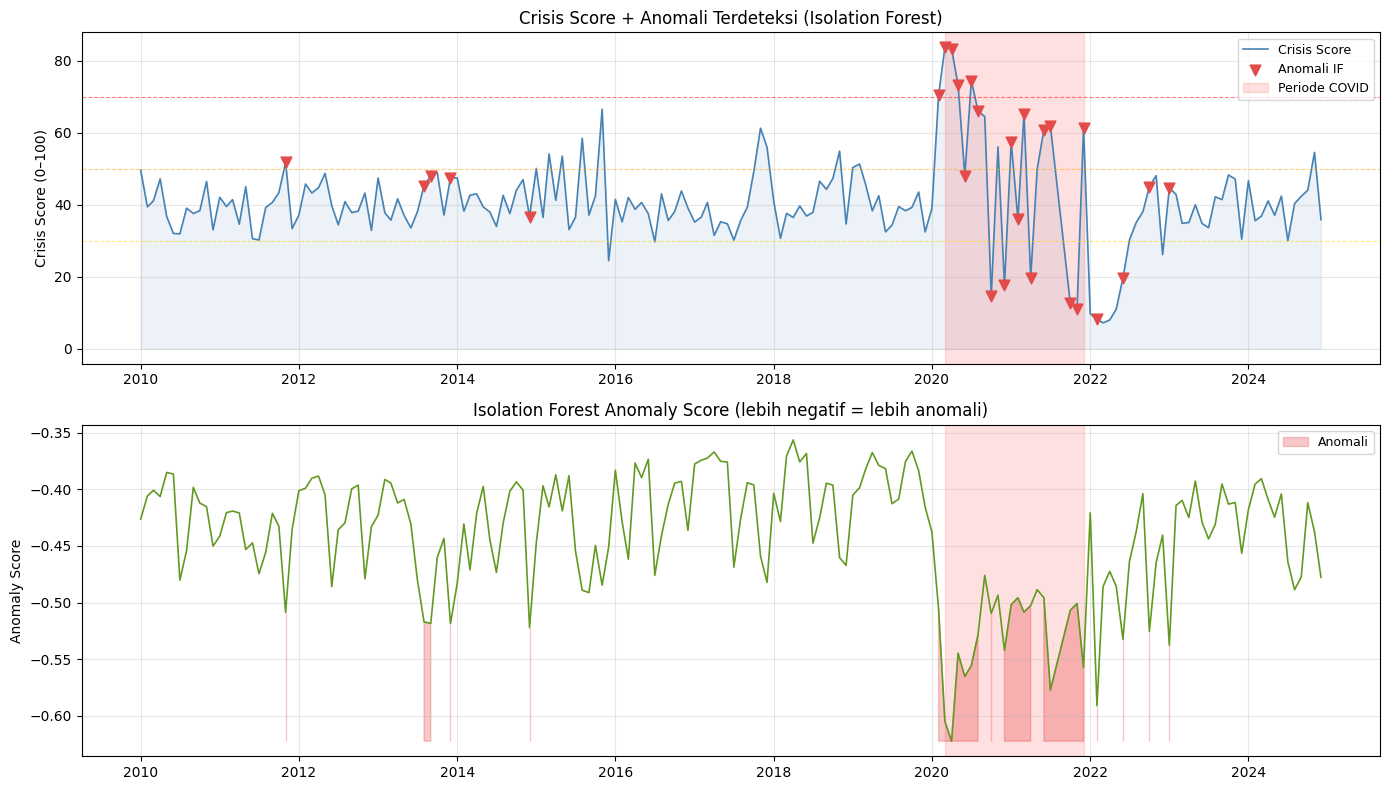

✅ Plot disimpan ke data/final/isolation_forest_results.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Crisis score + anomali markers
ax1 = axes[0]
months_dt = pd.to_datetime(df_model['month'].astype(str))
ax1.plot(months_dt, df_model['crisis_score_100'], color='steelblue', linewidth=1.2, label='Crisis Score')
ax1.fill_between(months_dt, 0, df_model['crisis_score_100'], alpha=0.1, color='steelblue')

# Anomali markers
anomali_mask = df_model['iso_anomaly'] == 1
ax1.scatter(months_dt[anomali_mask], df_model['crisis_score_100'][anomali_mask],
            color='#E24B4A', s=60, zorder=5, label='Anomali IF', marker='v')

# COVID shading
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-12-01')
ax1.axvspan(covid_start, covid_end, alpha=0.12, color='red', label='Periode COVID')
ax1.axhline(70, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axhline(30, color='gold', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_title('Crisis Score + Anomali Terdeteksi (Isolation Forest)', fontsize=12)
ax1.set_ylabel('Crisis Score (0–100)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Anomaly score timeline
ax2 = axes[1]
ax2.plot(months_dt, df_model['iso_score'], color='#639922', linewidth=1.2)
ax2.fill_between(months_dt, df_model['iso_score'].min(), df_model['iso_score'],
                 where=df_model['iso_anomaly']==1, alpha=0.3, color='#E24B4A', label='Anomali')
ax2.axvspan(covid_start, covid_end, alpha=0.12, color='red')
ax2.set_title('Isolation Forest Anomaly Score (lebih negatif = lebih anomali)', fontsize=12)
ax2.set_ylabel('Anomaly Score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('data/final', exist_ok=True)
plt.savefig('data/final/isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot disimpan ke data/final/isolation_forest_results.png')

## 6. Model 2 — Random Forest Classifier (Crisis Level Prediction)

**Random Forest** memprediksi level krisis (AMAN/WASPADA/SIAGA/KRISIS) berdasarkan semua fitur.
Menggunakan **TimeSeriesSplit** untuk evaluasi — tidak boleh random split pada data time series.

In [10]:
# TimeSeriesSplit untuk evaluasi (respek urutan waktu)
tscv = TimeSeriesSplit(n_splits=5)

# Model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',   # handle imbalance KRISIS vs AMAN
    random_state=42,
    n_jobs=-1
)

# Cross-validation dengan TimeSeriesSplit
print('=== TIME SERIES CROSS VALIDATION (5-fold) ===')
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=tscv, scoring='accuracy')
print(f'Accuracy per fold: {[f"{s:.3f}" for s in cv_scores]}')
print(f'Mean accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print()

# CV dengan metric tambahan (F1 macro — lebih adil untuk imbalanced data)
cv_f1 = cross_val_score(rf_model, X_scaled, y, cv=tscv, scoring='f1_macro')
print(f'F1 Macro per fold: {[f"{s:.3f}" for s in cv_f1]}')
print(f'Mean F1 Macro   : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print('(F1 Macro lebih representatif untuk data tidak seimbang)')
print()

# Train pada seluruh data (untuk deployment)
rf_model.fit(X_scaled, y)
y_pred = rf_model.predict(X_scaled)
y_pred_labels = le.inverse_transform(y_pred)

print('=== CLASSIFICATION REPORT (full training data) ===')
print(classification_report(
    le.inverse_transform(y),
    y_pred_labels,
    target_names=label_order,
    zero_division=0
))

=== TIME SERIES CROSS VALIDATION (5-fold) ===
Accuracy per fold: ['0.966', '0.793', '0.862', '0.345', '0.931']
Mean accuracy: 0.779 ± 0.225

F1 Macro per fold: ['0.491', '0.295', '0.497', '0.181', '0.543']
Mean F1 Macro   : 0.401 ± 0.140
(F1 Macro lebih representatif untuk data tidak seimbang)

=== CLASSIFICATION REPORT (full training data) ===
              precision    recall  f1-score   support

        AMAN       0.75      1.00      0.86         6
     WASPADA       1.00      1.00      1.00         5
       SIAGA       1.00      0.97      0.98        31
      KRISIS       1.00      0.99      1.00       136

    accuracy                           0.99       178
   macro avg       0.94      0.99      0.96       178
weighted avg       0.99      0.99      0.99       178



### 6.1 Confusion Matrix

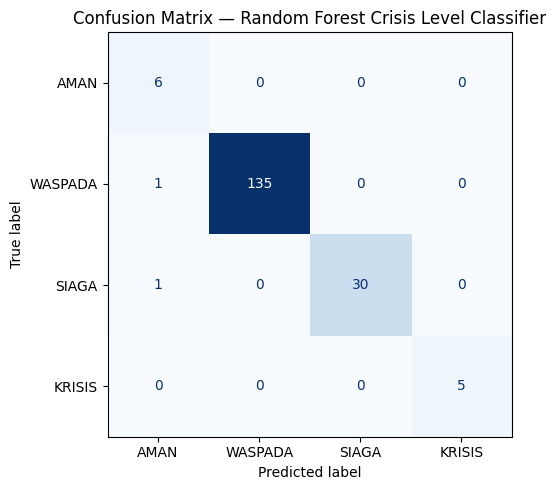

✅ Confusion matrix disimpan


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(le.inverse_transform(y), y_pred_labels, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest Crisis Level Classifier', fontsize=12)
plt.tight_layout()
plt.savefig('data/final/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix disimpan')

### 6.2 Feature Importance

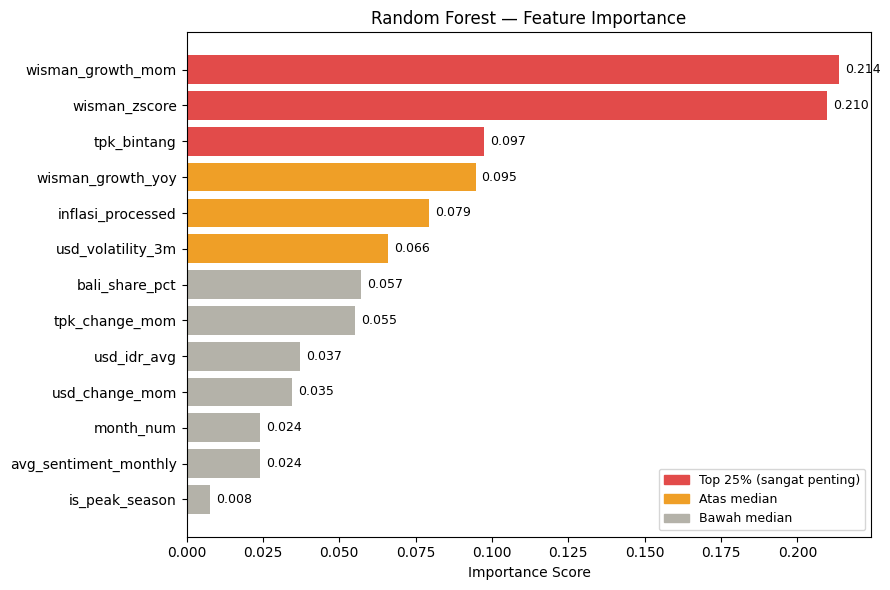

Top 5 fitur terpenting:
             feature  importance
0  wisman_growth_mom    0.213548
2      wisman_zscore    0.209820
6        tpk_bintang    0.097318
1  wisman_growth_yoy    0.094601
8  inflasi_processed    0.079341


In [12]:
# Feature importance dari Random Forest
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E24B4A' if v > fi_df['importance'].quantile(0.75) else
          '#EF9F27' if v > fi_df['importance'].median() else
          '#B4B2A9' for v in fi_df['importance']]

bars = ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
ax.set_title('Random Forest — Feature Importance', fontsize=12)
ax.set_xlabel('Importance Score')

# Annotate
for bar, val in zip(bars, fi_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#E24B4A', label='Top 25% (sangat penting)'),
    mpatches.Patch(color='#EF9F27', label='Atas median'),
    mpatches.Patch(color='#B4B2A9', label='Bawah median'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('data/final/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 fitur terpenting:')
print(fi_df.tail(5)[['feature','importance']].sort_values('importance', ascending=False).to_string())

## 7. SHAP — Explainability

**SHAP (SHapley Additive exPlanations)** menjelaskan *mengapa* model membuat prediksi tertentu.
Untuk setiap prediksi, SHAP menunjukkan kontribusi positif/negatif dari setiap fitur.

Shape SHAP values: (178, 13, 4)
Classes: [np.str_('AMAN'), np.str_('KRISIS'), np.str_('SIAGA'), np.str_('WASPADA')]
SHAP array shape: (178, 13, 4)
Shape SHAP untuk KRISIS: (178, 13)
Shape X_scaled: (178, 13)



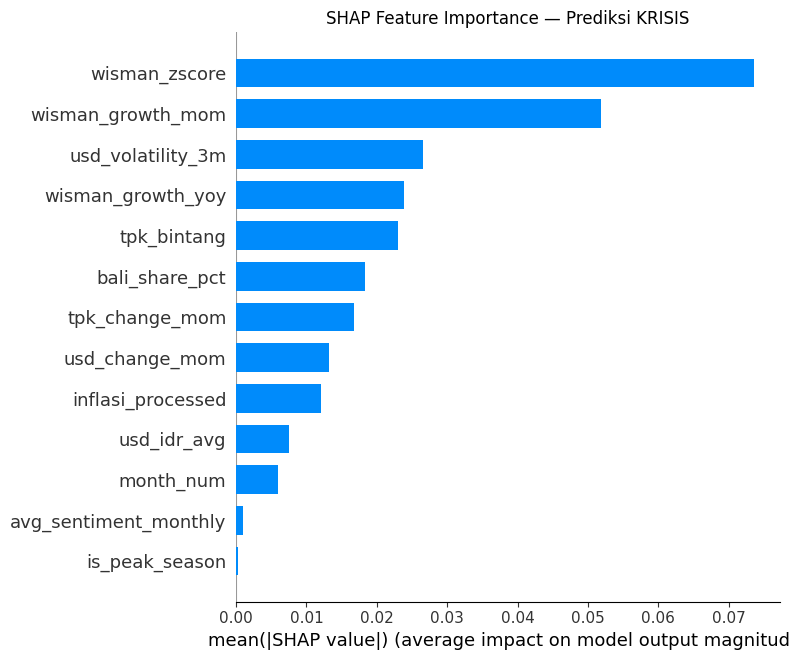

✅ SHAP summary plot disimpan


In [13]:
try:
    import shap

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_scaled)

    print('Shape SHAP values:', np.array(shap_values).shape)
    print('Classes:', list(le.classes_))

    # ✅ FIX: Handle dua kemungkinan format output SHAP
    # Format lama: list of arrays [n_classes][n_samples, n_features]
    # Format baru: single array [n_samples, n_features, n_classes]
    shap_arr = np.array(shap_values)
    print('SHAP array shape:', shap_arr.shape)

    krisis_idx = list(le.classes_).index('KRISIS')

    if shap_arr.ndim == 3:
        # Format baru: (n_samples, n_features, n_classes)
        shap_krisis = shap_arr[:, :, krisis_idx]
    else:
        # Format lama: (n_classes, n_samples, n_features)
        shap_krisis = shap_arr[krisis_idx]

    print('Shape SHAP untuk KRISIS:', shap_krisis.shape)
    print('Shape X_scaled:', X_scaled.shape)
    print()

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_krisis,
        X_scaled,
        feature_names=FEATURES,
        plot_type='bar',
        show=False
    )
    plt.title('SHAP Feature Importance — Prediksi KRISIS', fontsize=12)
    plt.tight_layout()
    plt.savefig('data/final/shap_summary_krisis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP summary plot disimpan')

except ImportError:
    print('⚠️  SHAP tidak tersedia. Install dengan: pip install shap')

### 7.1 SHAP Beeswarm Plot — Detail Kontribusi Fitur

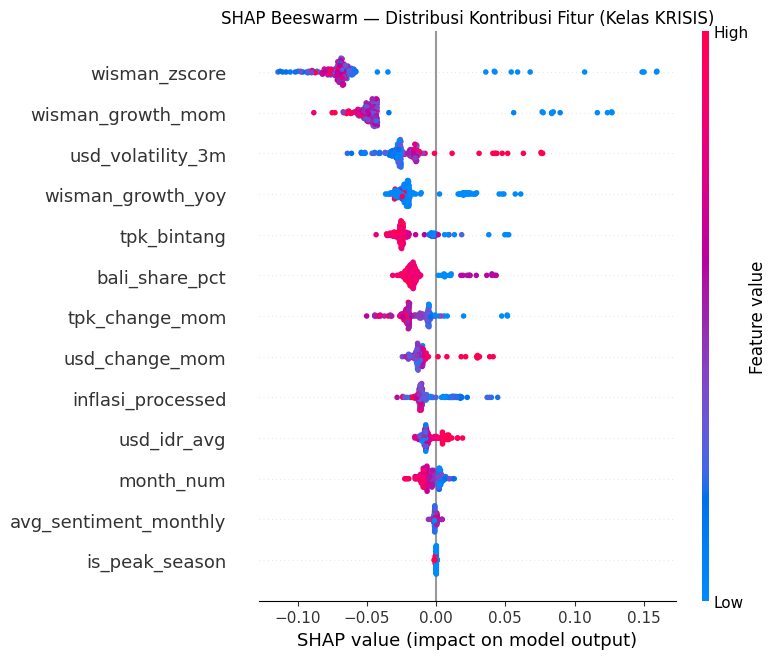

✅ SHAP beeswarm disimpan

=== SHAP ANALISIS: Maret 2020 (puncak krisis) ===
                  feature  shap_value  feature_value
2           wisman_zscore      0.1594        -2.3761
0       wisman_growth_mom      0.1268        -0.0955
4       usd_volatility_3m      0.0758         4.6140
1       wisman_growth_yoy      0.0611        -0.1475
7          tpk_change_mom      0.0513        -3.3329
9          bali_share_pct      0.0434        -1.0156
5          usd_change_mom      0.0412         2.9682
8       inflasi_processed      0.0385        -0.6551
6             tpk_bintang      0.0185        -1.6800
3             usd_idr_avg      0.0155         1.0167
11              month_num      0.0122        -1.0038
10  avg_sentiment_monthly      0.0023         0.1304
12         is_peak_season      0.0009        -0.5730


In [14]:
try:
    import shap

    # ✅ FIX: Pakai shap_krisis yang sudah difix di cell sebelumnya
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_krisis,        # ← ganti dari shap_krisis
        X_scaled,
        feature_names=FEATURES,
        plot_type='dot',
        show=False
    )
    plt.title('SHAP Beeswarm — Distribusi Kontribusi Fitur (Kelas KRISIS)', fontsize=12)
    plt.tight_layout()
    plt.savefig('data/final/shap_beeswarm_krisis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP beeswarm disimpan')

    # Analisis bulan Mar 2020
    mar2020_idx = df_model[df_model['month'] == '2020-03'].index
    if len(mar2020_idx) > 0:
        idx_in_model = df_model.index.get_loc(mar2020_idx[0])
        print()
        print('=== SHAP ANALISIS: Maret 2020 (puncak krisis) ===')
        # ✅ FIX: pakai shap_krisis bukan shap_krisis
        krisis_shap_row = shap_krisis[idx_in_model]
        shap_explain = pd.DataFrame({
            'feature': FEATURES,
            'shap_value': krisis_shap_row,
            'feature_value': X_scaled[idx_in_model]
        }).sort_values('shap_value', ascending=False)
        print(shap_explain.round(4).to_string())

except ImportError:
    print('⚠️  Skip SHAP beeswarm — SHAP tidak terinstall')

## 8. Gabungkan Semua Prediksi

In [15]:
# Gabungkan semua prediksi ke satu dataframe
df_model['rf_predicted_level'] = y_pred_labels
df_model['rf_correct'] = (df_model['rf_predicted_level'] == df_model[TARGET])

# Hitung confidence (max probability dari RF)
y_proba = rf_model.predict_proba(X_scaled)
df_model['rf_confidence'] = y_proba.max(axis=1)

# Mapping probabilitas per kelas
for i, cls in enumerate(le.classes_):
    df_model[f'prob_{cls.lower()}'] = y_proba[:, i]

print('=== RINGKASAN PREDIKSI ===')
print(f'Accuracy keseluruhan: {accuracy_score(y, y_pred)*100:.1f}%')
print()
print('Prediksi per periode kritis:')
kritis_periods = df_model[df_model[TARGET].isin(['SIAGA','KRISIS'])]
print(kritis_periods[['month','crisis_score_100',TARGET,'rf_predicted_level','rf_confidence']].to_string())

=== RINGKASAN PREDIKSI ===
Accuracy keseluruhan: 98.9%

Prediksi per periode kritis:
       month  crisis_score_100 crisis_level rf_predicted_level  rf_confidence
34   2011-11         51.769859        SIAGA              SIAGA       0.534746
72   2015-01         50.067171        SIAGA              SIAGA       0.622853
74   2015-03         54.096131        SIAGA              SIAGA       0.792703
76   2015-05         53.469674        SIAGA              SIAGA       0.651122
79   2015-08         58.446355        SIAGA              SIAGA       0.695772
82   2015-11         66.506344        SIAGA              SIAGA       0.711910
106  2017-11         61.228565        SIAGA              SIAGA       0.757497
107  2017-12         55.961307        SIAGA              SIAGA       0.663690
118  2018-11         54.851169        SIAGA              SIAGA       0.749222
120  2019-01         50.320305        SIAGA              SIAGA       0.714558
121  2019-02         51.276583        SIAGA              

## 9. Simpan Model & Output

In [16]:
os.makedirs('data/final', exist_ok=True)
os.makedirs('data/models', exist_ok=True)

# Simpan model
joblib.dump(iso_forest, 'data/models/model_isolation_forest.pkl')
joblib.dump(rf_model,   'data/models/model_random_forest.pkl')
joblib.dump(scaler,     'data/models/scaler.pkl')
joblib.dump(le,         'data/models/label_encoder.pkl')

print('✅ Model disimpan ke data/models/')
print('   - model_isolation_forest.pkl')
print('   - model_random_forest.pkl')
print('   - scaler.pkl')
print('   - label_encoder.pkl')

# Simpan prediksi final
output_cols = [
    'month', 'wisman', 'tpk_bintang', 'inflasi_processed',
    'usd_idr_avg', 'avg_sentiment_monthly',
    'bali_share_pct', 'wisman_zscore',   # ✅ FIX: dibutuhkan dashboard
    'crisis_score_100', TARGET, 'rf_predicted_level', 'rf_confidence',
    'prob_aman', 'prob_waspada', 'prob_siaga', 'prob_krisis',
    'iso_anomaly', 'iso_score'
]
# ✅ FIX: merge kolom extra dari master jika belum ada di df_model
extra_needed = ['bali_share_pct', 'wisman_zscore']
for col in extra_needed:
    if col not in df_model.columns and col in master.columns:
        master_col = master[['month', col]].copy()
        master_col['month'] = master_col['month'].astype(str)
        df_model = df_model.merge(master_col, on='month', how='left')

output_cols = [c for c in output_cols if c in df_model.columns]
predictions_df = df_model[output_cols].copy()
predictions_df.to_csv('data/final/predictions_final.csv', index=False)

print()
print('✅ Prediksi disimpan ke data/final/predictions_final.csv')
print(f'   Shape: {predictions_df.shape}')

✅ Model disimpan ke data/models/
   - model_isolation_forest.pkl
   - model_random_forest.pkl
   - scaler.pkl
   - label_encoder.pkl

✅ Prediksi disimpan ke data/final/predictions_final.csv
   Shape: (178, 18)


## 10. Visualisasi Akhir — Crisis Timeline dengan Prediksi

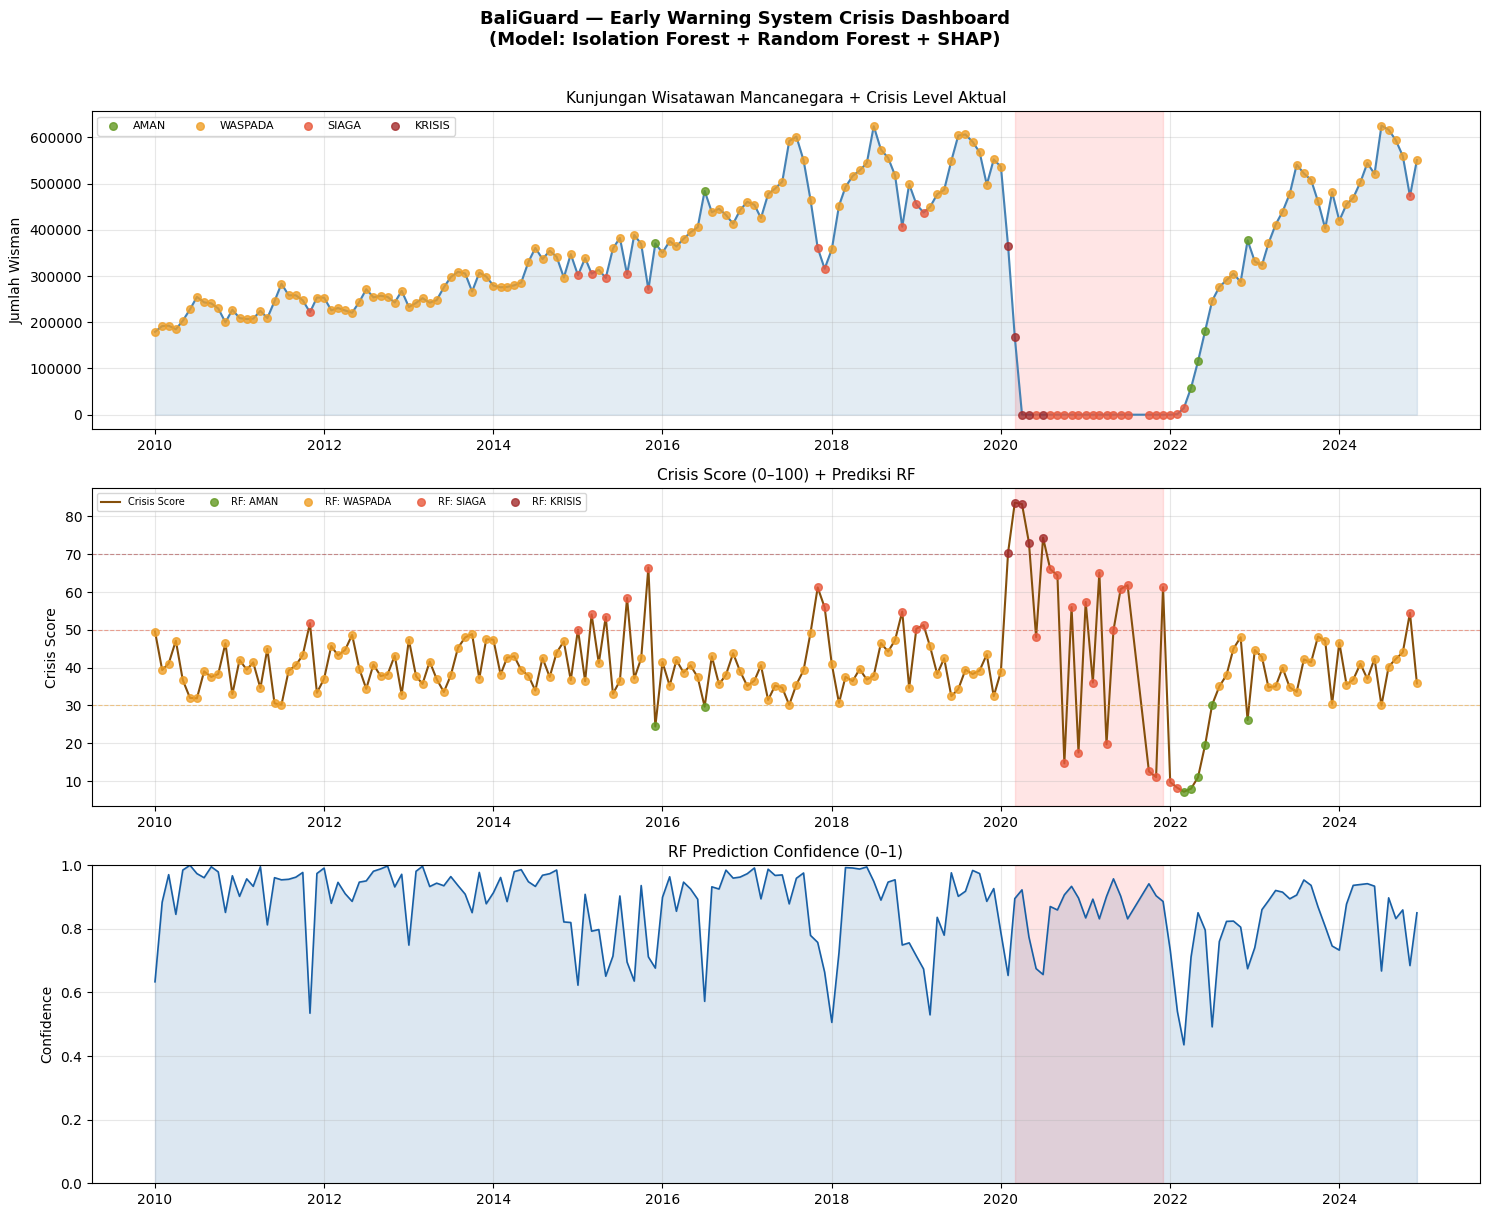

✅ Plot final disimpan ke data/final/crisis_timeline_final.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
months_dt = pd.to_datetime(df_model['month'].astype(str))

color_map = {'AMAN': '#639922', 'WASPADA': '#EF9F27', 'SIAGA': '#E8593C', 'KRISIS': '#A32D2D'}

# Plot 1: Wisman dengan crisis level
ax1 = axes[0]
ax1.plot(months_dt, df_model['wisman'], color='steelblue', linewidth=1.5)
ax1.fill_between(months_dt, 0, df_model['wisman'], alpha=0.15, color='steelblue')
for level, color in color_map.items():
    mask = df_model[TARGET] == level
    ax1.scatter(months_dt[mask], df_model['wisman'][mask],
                color=color, s=30, zorder=5, label=level, alpha=0.8)
ax1.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax1.set_title('Kunjungan Wisatawan Mancanegara + Crisis Level Aktual', fontsize=11)
ax1.set_ylabel('Jumlah Wisman')
ax1.legend(fontsize=8, ncol=4)
ax1.grid(alpha=0.3)

# Plot 2: Crisis score + RF prediction
ax2 = axes[1]
ax2.plot(months_dt, df_model['crisis_score_100'], color='#854F0B', linewidth=1.5, label='Crisis Score')
for level, color in color_map.items():
    mask = df_model['rf_predicted_level'] == level
    ax2.scatter(months_dt[mask], df_model['crisis_score_100'][mask],
                color=color, s=30, zorder=5, alpha=0.8, label=f'RF: {level}')
ax2.axhline(70, color='#A32D2D', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(50, color='#E8593C', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(30, color='#EF9F27', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax2.set_title('Crisis Score (0–100) + Prediksi RF', fontsize=11)
ax2.set_ylabel('Crisis Score')
ax2.legend(fontsize=7, ncol=5)
ax2.grid(alpha=0.3)

# Plot 3: RF confidence
ax3 = axes[2]
ax3.plot(months_dt, df_model['rf_confidence'], color='#185FA5', linewidth=1.2)
ax3.fill_between(months_dt, 0, df_model['rf_confidence'], alpha=0.15, color='#185FA5')
ax3.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax3.set_title('RF Prediction Confidence (0–1)', fontsize=11)
ax3.set_ylabel('Confidence')
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.3)

plt.suptitle('BaliGuard — Early Warning System Crisis Dashboard\n(Model: Isolation Forest + Random Forest + SHAP)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/final/crisis_timeline_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot final disimpan ke data/final/crisis_timeline_final.png')

## 11. Ringkasan Model

In [18]:
print('=' * 55)
print('  BALIGUARD — RINGKASAN MODEL NB05')
print('=' * 55)
print()
print('📊 Dataset:')
print(f'   {len(df_model)} baris × {len(FEATURES)} fitur')
print(f'   Periode: {df_model["month"].min()} → {df_model["month"].max()}')
print()
print('🌲 Isolation Forest:')
print(f'   Contamination: 15%')
print(f'   Anomali terdeteksi: {df_model["iso_anomaly"].sum()} bulan')
covid_detected = df_model[
    df_model['month'].between('2020-01','2021-12') &
    (df_model['iso_anomaly']==1)
]
print(f'   COVID months terdeteksi: {len(covid_detected)}/{len(df_model[df_model["month"].between("2020-01","2021-12")])}')
print()
print('🌳 Random Forest Classifier:')
acc = accuracy_score(y, y_pred) * 100
print(f'   Accuracy (training): {acc:.1f}%')
print(f'   CV Accuracy (5-fold TimeSeriesSplit): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'   CV F1 Macro  (5-fold TimeSeriesSplit): {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print(f'   n_estimators: 300, max_depth: 8')
print(f'   class_weight: balanced')
print()
print('💾 Output tersimpan:')
print('   data/models/model_isolation_forest.pkl')
print('   data/models/model_random_forest.pkl')
print('   data/models/scaler.pkl')
print('   data/models/label_encoder.pkl')
print('   data/final/predictions_final.csv')
print()
print('🎯 Langkah selanjutnya: NB06 — LLM Narrative Engine + Dashboard Streamlit')
print('=' * 55)

  BALIGUARD — RINGKASAN MODEL NB05

📊 Dataset:
   178 baris × 13 fitur
   Periode: 2010-01 → 2024-12

🌲 Isolation Forest:
   Contamination: 15%
   Anomali terdeteksi: 27 bulan
   COVID months terdeteksi: 18/22

🌳 Random Forest Classifier:
   Accuracy (training): 98.9%
   CV Accuracy (5-fold TimeSeriesSplit): 0.779 ± 0.225
   CV F1 Macro  (5-fold TimeSeriesSplit): 0.401 ± 0.140
   n_estimators: 300, max_depth: 8
   class_weight: balanced

💾 Output tersimpan:
   data/models/model_isolation_forest.pkl
   data/models/model_random_forest.pkl
   data/models/scaler.pkl
   data/models/label_encoder.pkl
   data/final/predictions_final.csv

🎯 Langkah selanjutnya: NB06 — LLM Narrative Engine + Dashboard Streamlit
